# Kinase-focused analysis (KSEA-like prerank)

This notebook **interprets and visualizes** kinase–substrate enrichment from this repo. It does **not** re-run gseapy by default (use the CLI for heavy compute).

**Prerequisites**

1. Run `python analyze/kinase_substrate_prerank.py` (or `python run_all.py`) so `output/analyze/ksea_prerank_long.tsv` exists.
2. A kinase GMT at `data/gene_sets/kinase_substrates.gmt` (or the bundled `kinase_substrates_sample.gmt` used when the full file is absent).
3. Optional: `output/analyze/leading_edge_followup/leading_edge_kinase_fisher.tsv` after `analyze/leading_edge_kinase_overlap.py` / `leading_edge_followup_all.py`.

Working directory can be repo root or `notebooks/` — the next cell finds the project root via `data.tsv` + `analyze/_conditions.py`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

def find_project_root() -> Path:
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "data.tsv").is_file() and (p / "analyze" / "_conditions.py").is_file():
            return p
    raise FileNotFoundError("Project root not found (need data.tsv and analyze/_conditions.py).")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "analyze"))
from _conditions import CONDITIONS, TEMPORAL_ARMS  # noqa: E402

KSEA_LONG = ROOT / "output" / "analyze" / "ksea_prerank_long.tsv"
DATA_TSV = ROOT / "data.tsv"
GMT_FULL = ROOT / "data" / "gene_sets" / "kinase_substrates.gmt"
GMT_SAMPLE = ROOT / "data" / "gene_sets" / "kinase_substrates_sample.gmt"
FISHER_TSV = ROOT / "output" / "analyze" / "leading_edge_followup" / "leading_edge_kinase_fisher.tsv"

pd.set_option("display.max_rows", 25)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

COND_ORDER = [c.condition_id for c in CONDITIONS]


def parse_gmt(path: Path) -> dict[str, list[str]]:
    out: dict[str, list[str]] = {}
    if not path.is_file():
        return out
    with path.open(encoding="utf-8", errors="replace") as fh:
        for line in fh:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            name = parts[0].strip()
            genes = [p.strip() for p in parts[2:] if p.strip()]
            if name:
                out[name] = genes
    return out


GMT_PATH = GMT_FULL if GMT_FULL.is_file() else GMT_SAMPLE
GMT_SETS = parse_gmt(GMT_PATH)

print("ROOT =", ROOT)
print("GMT =", GMT_PATH, "->", len(GMT_SETS), "kinase sets")


ROOT = /Users/ph/Documents/phospho_mhg_anno
GMT = /Users/ph/Documents/phospho_mhg_anno/data/gene_sets/kinase_substrates.gmt -> 263 kinase sets


## Recompute enrichment (CLI)

From the repo root:

```bash
python analyze/build_kinase_gmt.py   # if you need a fresh GMT from PhosphoSite
python analyze/kinase_substrate_prerank.py
```

Then re-run this notebook so plots match the new `ksea_prerank_long.tsv`.

## Methods primer

### What this pipeline does

- **Input:** per-condition **gene rank lists** (`.rnk`) built from phospho `data.tsv`: each gene gets one **RankScore** (max-|site score| style aggregation; see `generate_rank_lists.py`).
- **Test:** **gseapy prerank** (GSEA-style) against **kinase → substrate gene** sets from a **GMT** (PhosphoSite-style tables via `build_kinase_gmt.py`).
- **Outputs:** nominal **p-value**, **FDR**, **NES**, **leading-edge substrate genes** per kinase per condition (`ksea_prerank_long.tsv`).

### KSEA vs this approach

- **Classic KSEA** is often **site-weighted** or uses explicit substrate weights.
- **Here:** enrichment is at the **gene** level after collapsing sites into one rank score — same *spirit* (which kinase’s substrates sit at the regulated tail of the list?) but **not** identical to published site-level KSEA.

### Caveats (typical for phosphoproteomics + literature sets)

- **Many simultaneous tests** (many kinases) → treat **FDR** as strict and **nominal p** as exploratory when scanning heatmaps.
- **GMT coverage:** biased toward well-studied kinases and interactions; **organism** and **gene symbol** matching must be consistent.
- **NES direction:** positive NES means substrates tend to rank toward the **top** of your `.rnk` (high RankScore); interpret with your scoring sign convention.

### mhm?

1. Which kinases are most significant **per condition** and **across** co-stimulation arms?
2. Are **5 min vs 10 min** profiles consistent (**temporal** concordance) within the same co-stim background?
3. Do kinase hits **agree** with **GO** pathway themes from the parallel GO prerank?
4. Do **leading-edge substrate genes** overlap GO leading-edge genes (orthogonal check)?

In [2]:
if not KSEA_LONG.is_file():
    raise FileNotFoundError(f"Missing {KSEA_LONG}. Run: python analyze/kinase_substrate_prerank.py")

long = pd.read_csv(KSEA_LONG, sep="\t")
# normalize column names from gseapy
if "pval" not in long.columns and "NOM p-val" in long.columns:
    long = long.rename(columns={"NOM p-val": "pval"})
if "fdr" not in long.columns and "FDR q-val" in long.columns:
    long = long.rename(columns={"FDR q-val": "fdr"})

long["pval"] = pd.to_numeric(long["pval"], errors="coerce")
long["NES"] = pd.to_numeric(long.get("NES"), errors="coerce")
long["neglog10p"] = -np.log10(np.clip(long["pval"].to_numpy(), 1e-300, None))

display(long.head(10))
print("shape:", long.shape)


,condition,Name,Term,ES,NES,pval,fdr,FWER p-val,Tag %,Gene %,Lead_genes,kinase,neglog10p
0,αCD3_10min,prerank,ERK1,0.632138,1.456008,0.010067,0.974297,0.577,18/47,21.41%,CIC;MAPK3;BRAF;RAF1;NUP214;NUP153;PCBP2;ARHGEF...,ERK1,1.997095
1,αCD3_10min,prerank,Ret,0.902870,1.424077,0.022659,0.762288,0.726,3/5,7.55%,PLCG1;MAPK3;PDPK1,Ret,1.644767
2,αCD3_10min,prerank,p90RSK,0.694211,1.358205,0.072551,1.000000,0.924,5/16,12.72%,CIC;CHEK1;VASP;EIF4B;REPS1,p90RSK,1.139354
3,αCD3_10min,prerank,ERK2,0.581454,1.356843,0.027322,0.870397,0.927,21/54,22.23%,CIC;BRAF;NUP214;ERF;NUP153;RPS6KA1;PCBP2;CRTC2...,ERK2,1.563481
4,αCD3_10min,prerank,PKCA,0.597928,1.352845,0.055371,0.728513,0.933,8/41,8.78%,SPN;PLCG1;BCL11B;PRKAA1;RAF1;VASP;CD3G;KCNAB2,PKCA,1.256718
5,αCD3_10min,prerank,Fyn,0.700732,1.346892,0.068268,0.646726,0.947,5/15,15.01%,BSG;AGAP2;NMT1;PECAM1;RPS6KA3,Fyn,1.165783
6,αCD3_10min,prerank,CDK9,-0.687496,-1.337747,0.170819,1.000000,0.916,4/7,12.63%,SIRT1;NCOA2;POLR2A;BORA,CDK9,0.767465
7,αCD3_10min,prerank,Akt1,0.571674,1.317689,0.051087,0.743424,0.976,14/53,16.32%,PLCG1;PRKAA1;AGAP2;ACIN1;BRAF;CHEK1;BCL10;RICT...,Akt1,1.291690
8,αCD3_10min,prerank,CK1A,0.781407,1.315824,0.095568,0.661281,0.980,2/7,4.18%,YWHAQ;APC,CK1A,1.019688
9,αCD3_10min,prerank,Akt3,0.839359,1.310751,0.086257,0.618318,0.983,4/5,16.32%,BRAF;IWS1;ADAR;NF2,Akt3,1.064204


shape: (624, 13)


## Data inventory

,condition,n_kinase_rows
0,αCD3_10min,78
1,αCD3_5min,78
2,αCD3_αCD226_10min,78
3,αCD3_αCD226_5min,78
4,αCD3_αCD2_10min,78
5,αCD3_αCD2_5min,78
6,αCD3_αICOS_10min,78
7,αCD3_αICOS_5min,78


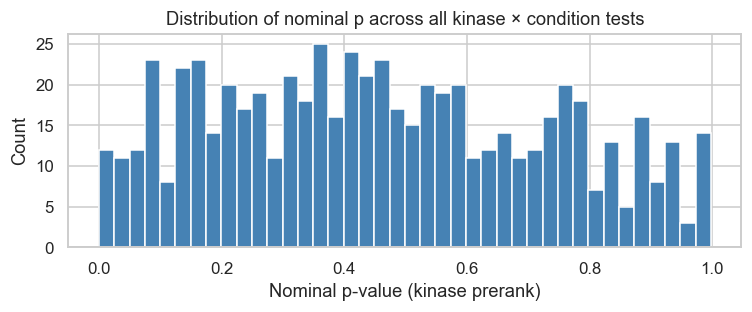

,substrates_per_kinase_in_gmt
count,263.000000
mean,26.585551
std,52.964046
min,3.000000
25%,5.000000
50%,9.000000
75%,22.500000
max,356.000000


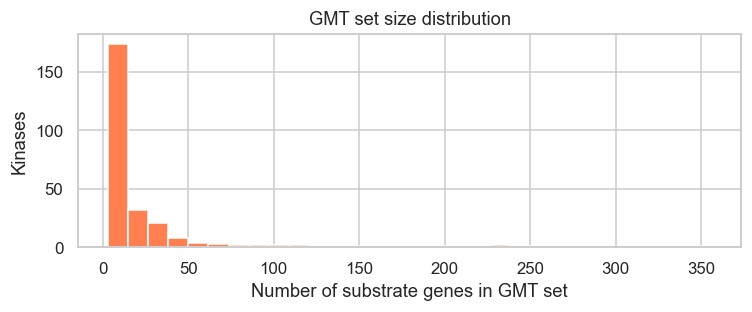

In [4]:
per_cond = long.groupby("condition").size().rename("n_kinase_rows").reset_index()
display(per_cond.sort_values("n_kinase_rows", ascending=False))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(long["pval"].dropna(), bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("Nominal p-value (kinase prerank)")
ax.set_ylabel("Count")
ax.set_title("Distribution of nominal p across all kinase × condition tests")
fig.tight_layout()
plt.show()

if GMT_SETS:
    sizes = pd.Series({k: len(v) for k, v in GMT_SETS.items()}).sort_values(ascending=False)
    display(sizes.describe().to_frame("substrates_per_kinase_in_gmt"))
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(sizes.to_numpy(), bins=min(30, max(5, len(sizes) // 3)), color="coral", edgecolor="white")
    ax.set_xlabel("Number of substrate genes in GMT set")
    ax.set_ylabel("Kinases")
    ax.set_title("GMT set size distribution")
    fig.tight_layout()
    plt.show()
else:
    print("No GMT parsed at", GMT_PATH)


## Kinase × condition heatmap (−log10 nominal p)

Restrict to the union of top `TOP_K` kinases per condition (same spirit as `kinase_substrate_prerank.py`).

**Note:** gseapy sometimes reports **nominal p = 0** after permutations. Here `−log10(p)` uses a floor of `1e-300` (so **300** on this scale). That single bright cell is usually **at the numeric ceiling**, not “infinitely” more significant than p≈1e-3 (**−log10 p ≈ 3**). The heatmap below **caps** the color scale so weaker but real signals are visible.

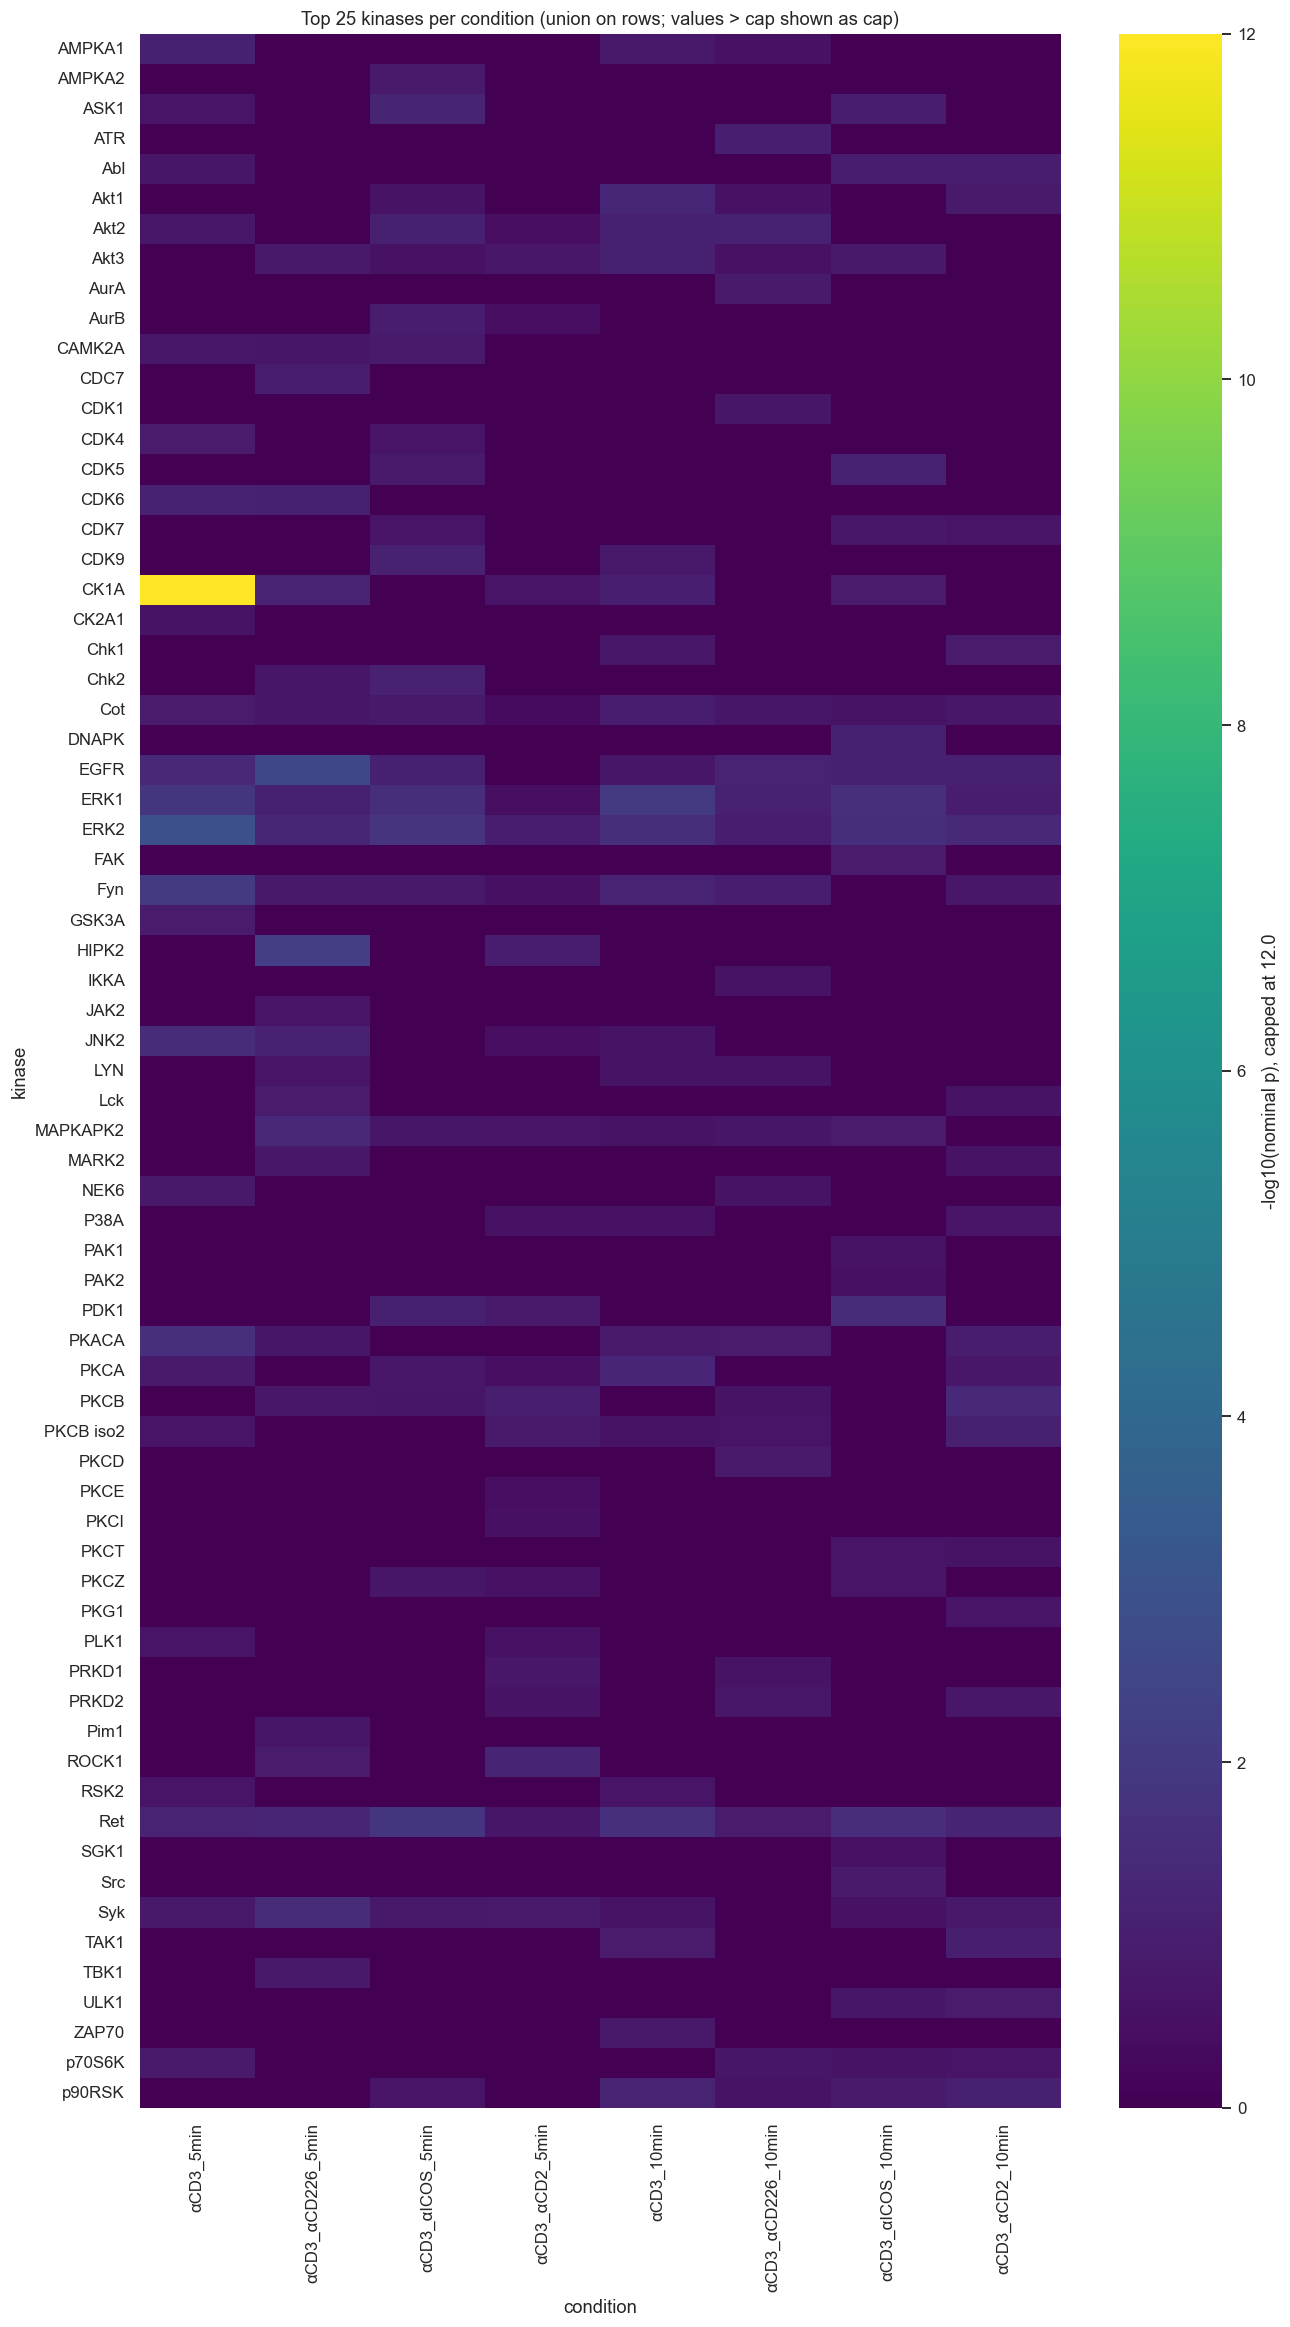

In [5]:
TOP_K = 25
CAP_NLP_HEATMAP = 12.0  # cap color scale (p≈0 -> 300 would wash out all other cells)

tops = []
for cid in COND_ORDER:
    sub = long[long["condition"] == cid].nlargest(TOP_K, "neglog10p")
    tops.append(sub)
topdf = pd.concat(tops, ignore_index=True)
kinases_order = sorted(topdf["kinase"].astype(str).unique())
mat_p = topdf.pivot_table(index="kinase", columns="condition", values="neglog10p", aggfunc="max")
mat_p = mat_p.reindex(index=[k for k in kinases_order if k in mat_p.index])
mat_p = mat_p[[c for c in COND_ORDER if c in mat_p.columns]]

mat_show = mat_p.fillna(0).clip(upper=CAP_NLP_HEATMAP)
fig_h = max(5.0, 0.28 * len(mat_p) + 2)
fig, ax = plt.subplots(figsize=(12, fig_h))
sns.heatmap(
    mat_show,
    cmap="viridis",
    ax=ax,
    vmin=0,
    vmax=CAP_NLP_HEATMAP,
    cbar_kws={"label": f"-log10(nominal p), capped at {CAP_NLP_HEATMAP}"},
)
ax.set_title(f"Top {TOP_K} kinases per condition (union on rows; values > cap shown as cap)")
fig.tight_layout()
plt.show()


## Bubble / dot grid (size = −log10 p, color = NES)

Same information as a heatmap but emphasizes **NES sign** and **strength** of evidence.

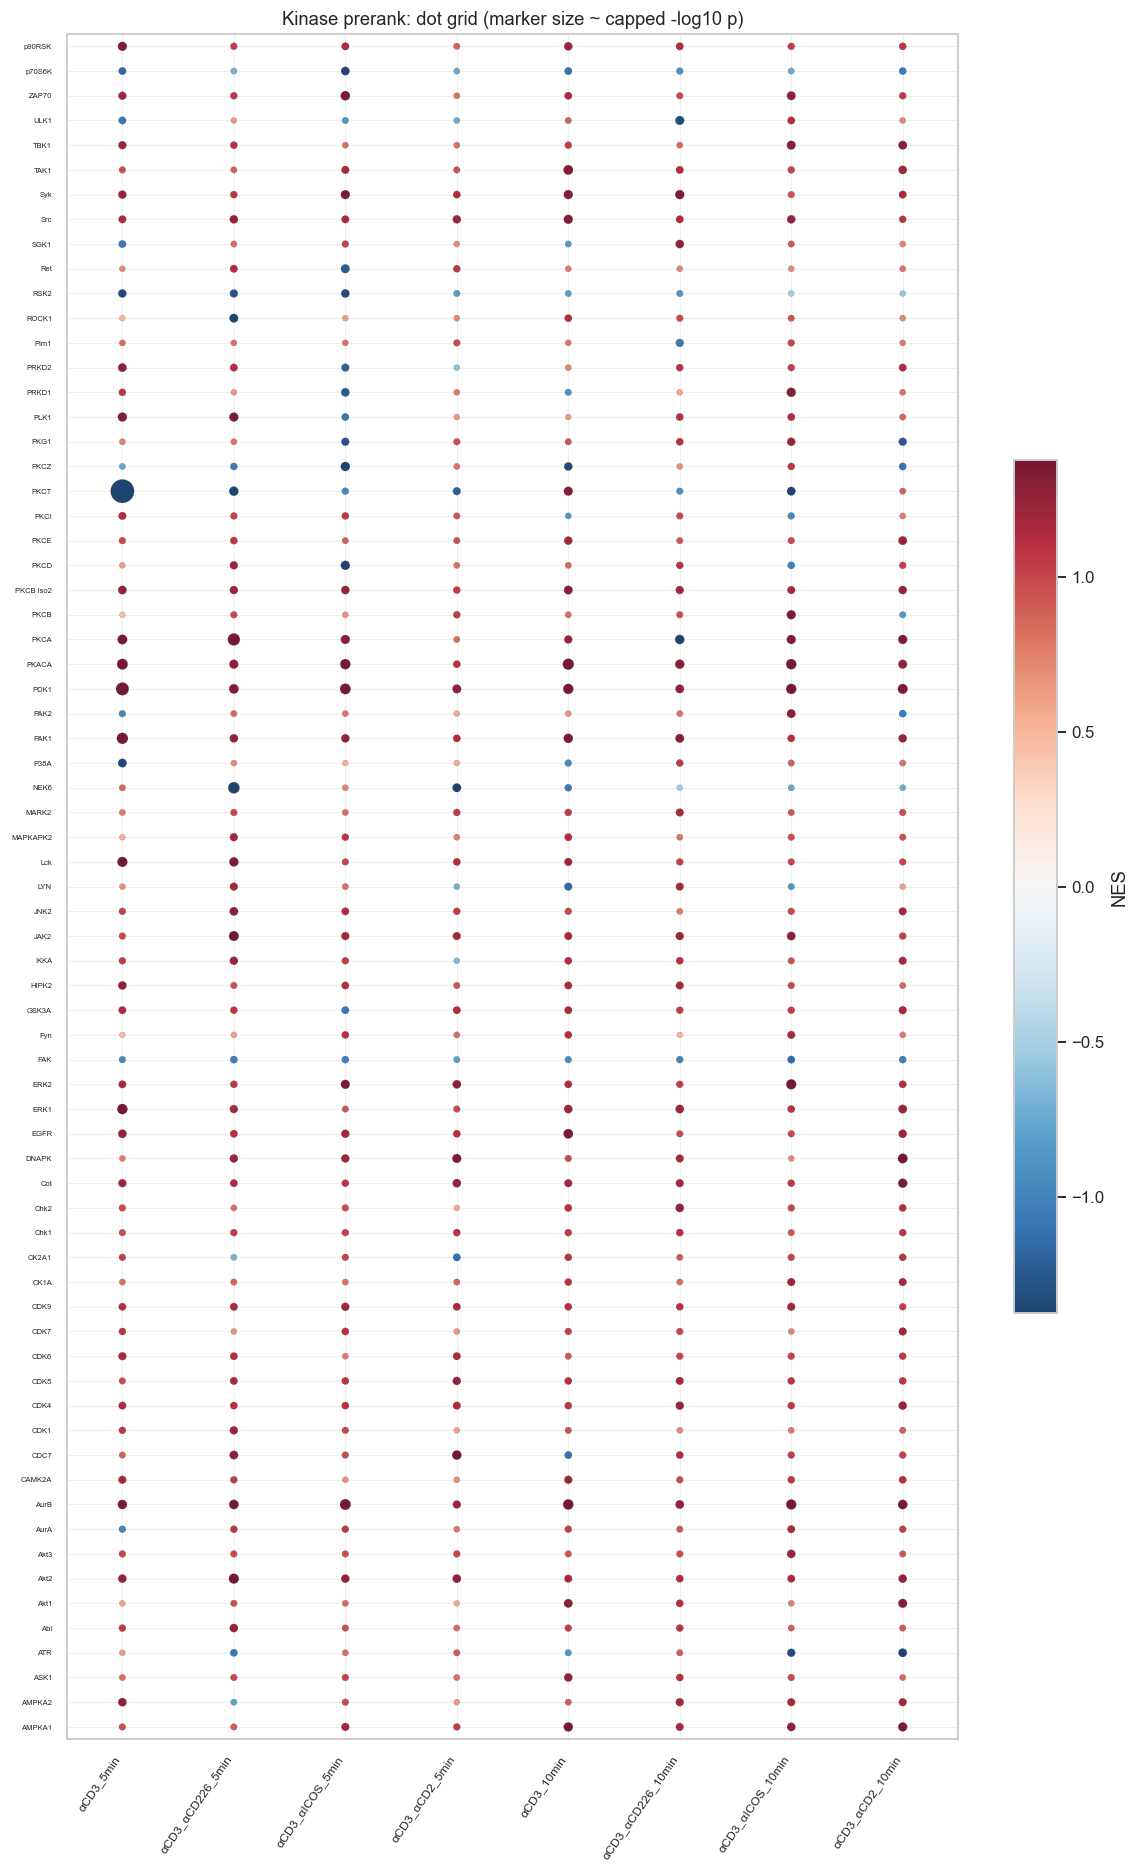

In [6]:
cap = 12.0
TOP_K_DOT = 25
tops = []
for cid in COND_ORDER:
    tops.append(long[long["condition"] == cid].nlargest(TOP_K_DOT, "neglog10p"))
topdf = pd.concat(tops, ignore_index=True)
kinases_u = sorted(topdf["kinase"].astype(str).unique())
mat_p = topdf.pivot_table(index="kinase", columns="condition", values="neglog10p", aggfunc="max")
mat_p = mat_p.reindex(index=[k for k in kinases_u if k in mat_p.index])
mat_p = mat_p[[c for c in COND_ORDER if c in mat_p.columns]]

wide_p = long.pivot_table(index="kinase", columns="condition", values="neglog10p", aggfunc="max")
wide_nes = long.pivot_table(index="kinase", columns="condition", values="NES", aggfunc="first")
idx = mat_p.index.intersection(wide_p.index).intersection(wide_nes.index)
wide_p = wide_p.loc[idx, [c for c in COND_ORDER if c in wide_p.columns]]
wide_nes = wide_nes.loc[idx, wide_p.columns]

vals = np.clip(wide_p.to_numpy(dtype=float), 0, cap)
nes_m = wide_nes.to_numpy(dtype=float)
n_term, n_cond = vals.shape
yy, xx = np.meshgrid(np.arange(n_term), np.arange(n_cond), indexing="ij")
flat_x = xx.ravel()
flat_y = (n_term - 1 - yy).ravel()
s_norm = np.clip(vals.ravel() / cap, 0, 1)
s_pts = 15 + s_norm * 220
flat_c = nes_m.ravel()
finite = np.isfinite(flat_c)
abs_n = float(np.nanpercentile(np.abs(nes_m[np.isfinite(nes_m)]), 95)) if np.any(np.isfinite(nes_m)) else 1.0
abs_n = max(abs_n, 0.3)

fig, ax = plt.subplots(figsize=(11, max(5, 0.22 * n_term + 2)))
if (~finite).any():
    ax.scatter(
        flat_x[~finite], flat_y[~finite], s=np.clip(s_pts[~finite], 8, 40), c="#999", alpha=0.45, rasterized=True
    )
if finite.any():
    sc = ax.scatter(
        flat_x[finite],
        flat_y[finite],
        c=flat_c[finite],
        s=s_pts[finite],
        cmap="RdBu_r",
        vmin=-abs_n,
        vmax=abs_n,
        edgecolors="0.25",
        linewidths=0.12,
        alpha=0.9,
        rasterized=True,
    )
    fig.colorbar(sc, ax=ax, shrink=0.5, label="NES")
ax.set_xticks(np.arange(n_cond))
ax.set_xticklabels(list(wide_p.columns), rotation=55, ha="right", fontsize=8)
ax.set_yticks(np.arange(n_term))
ax.set_yticklabels(list(wide_p.index), fontsize=max(4, min(8, 400 // max(n_term, 1))))
ax.set_xlim(-0.5, n_cond - 0.5)
ax.set_ylim(-0.5, n_term - 0.5)
ax.grid(True, color="0.88", lw=0.35)
ax.set_title("Kinase prerank: dot grid (marker size ~ capped -log10 p)")
fig.tight_layout()
plt.show()


## Temporal view (5 min vs 10 min, per co-stim arm)

For each arm in `TEMPORAL_ARMS`, scatter **−log10 p** at 5 min (x) vs 10 min (y) for kinases with **high variance** across those two timepoints (reduces overplotting).

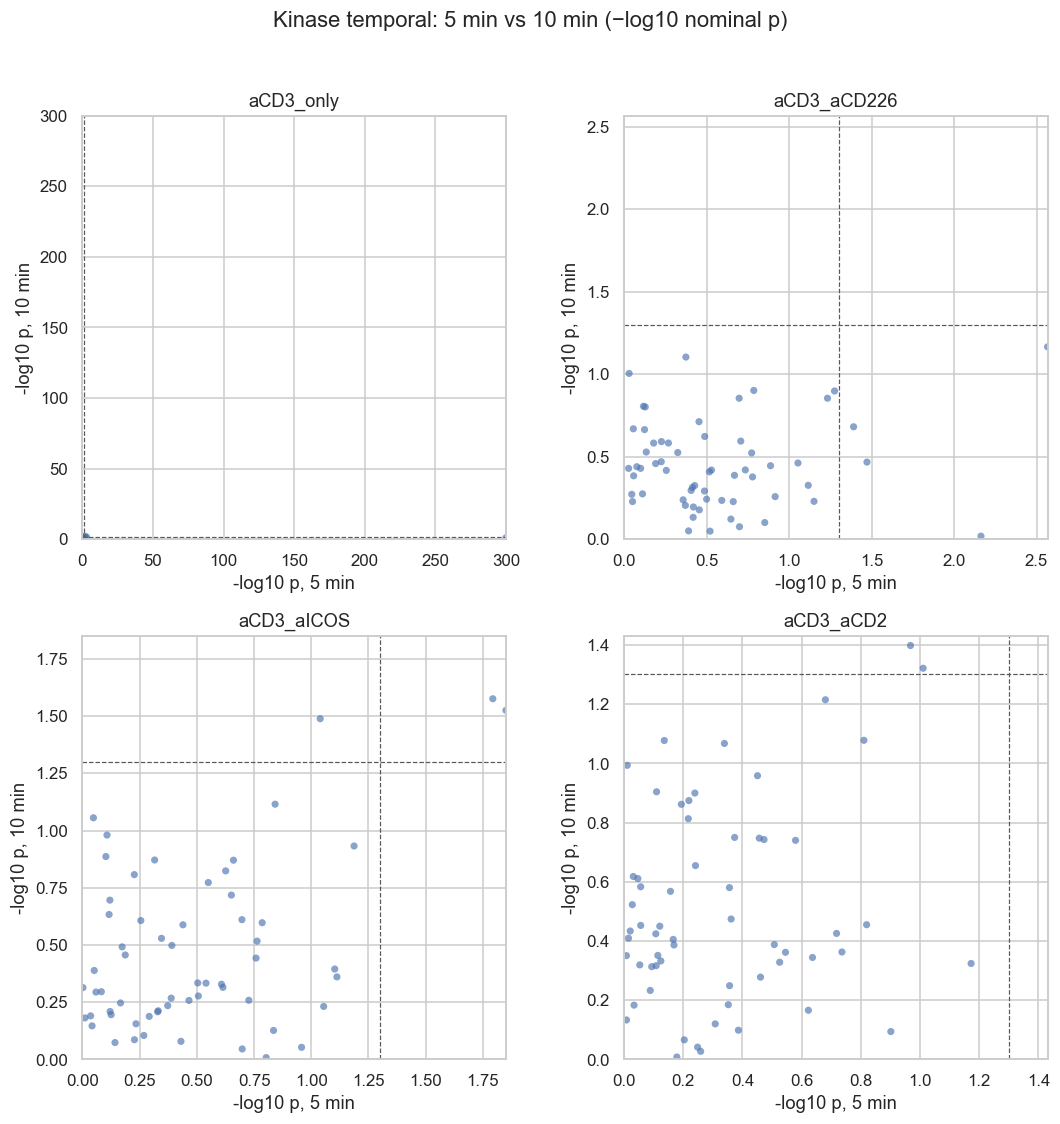

In [7]:
VAR_TOP = 60  # kinases per arm facet

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=False, sharey=False)
axes = axes.ravel()
thr = -np.log10(0.05)

for ax, arm in zip(axes, TEMPORAL_ARMS):
    a = long[long["condition"] == arm.t5_condition_id][["kinase", "pval", "neglog10p"]].rename(
        columns={"pval": "p5", "neglog10p": "nlp5"}
    )
    b = long[long["condition"] == arm.t10_condition_id][["kinase", "pval", "neglog10p"]].rename(
        columns={"pval": "p10", "neglog10p": "nlp10"}
    )
    m = a.merge(b, on="kinase", how="inner")
    if m.empty:
        ax.set_title(arm.arm_id + " (no overlap)")
        continue
    m["var_pair"] = m[["nlp5", "nlp10"]].var(axis=1)
    sub = m.nlargest(min(VAR_TOP, len(m)), "var_pair")
    ax.scatter(sub["nlp5"], sub["nlp10"], s=22, alpha=0.65, edgecolors="none", rasterized=True)
    ax.axvline(thr, color="0.35", ls="--", lw=0.8)
    ax.axhline(thr, color="0.35", ls="--", lw=0.8)
    ax.set_xlabel("-log10 p, 5 min")
    ax.set_ylabel("-log10 p, 10 min")
    ax.set_title(arm.arm_id)
    lo, hi = 0, float(max(sub["nlp5"].max(), sub["nlp10"].max(), thr * 1.1, 0.5))
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle("Kinase temporal: 5 min vs 10 min (−log10 nominal p)", y=1.02)
fig.tight_layout()
plt.show()


## NES concordance between two conditions

Edit `COND_A` and `COND_B`, then re-run the cell.

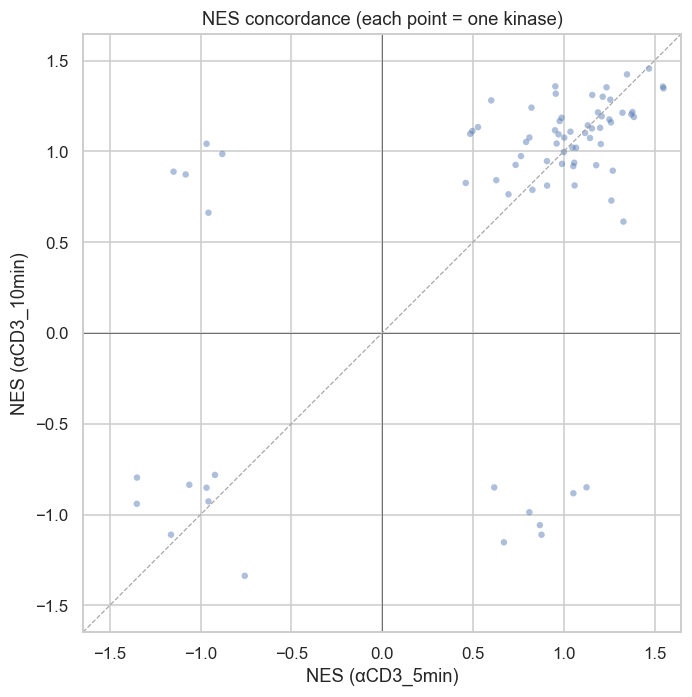

,kinase,NES_a,NES_b,delta_NES
59,ROCK1,0.877604,-1.111439,-1.989043
30,CK2A1,1.125652,-0.850307,-1.975959
37,CDK5,1.052881,-0.883017,-1.935898
60,HIPK2,0.868482,-1.058426,-1.926907
70,LYN,0.670371,-1.153118,-1.823489
64,ATM,0.810547,-0.987415,-1.797961
72,ULK1,0.617239,-0.850801,-1.468040
10,CDK6,1.328744,0.613079,-0.715665


,kinase,NES_a,NES_b,delta_NES
0,CK1A,-1.815346,1.315824,3.131169
27,LKB1,-1.149112,0.888194,2.037306
48,SGK1,-0.967398,1.041863,2.009261
32,ATR,-1.082397,0.872826,1.955223
58,JNK1,-0.880575,0.985905,1.866480
50,FAK,-0.956791,0.662178,1.618969
73,TAK1,0.600516,1.280867,0.680351
75,CDC7,0.497016,1.112387,0.615371


In [8]:
COND_A = "αCD3_5min"
COND_B = "αCD3_10min"

da = long[long["condition"] == COND_A][["kinase", "NES"]].rename(columns={"NES": "NES_a"})
db = long[long["condition"] == COND_B][["kinase", "NES"]].rename(columns={"NES": "NES_b"})
mm = da.merge(db, on="kinase", how="inner")
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(mm["NES_a"], mm["NES_b"], s=18, alpha=0.45, edgecolors="none", rasterized=True)
lims = float(np.nanpercentile(np.abs(mm[["NES_a", "NES_b"]].to_numpy()), 99)) + 0.1
lims = max(lims, 0.5)
ax.axhline(0, color="0.4", lw=0.6)
ax.axvline(0, color="0.4", lw=0.6)
ax.plot([-lims, lims], [-lims, lims], color="0.65", ls="--", lw=0.8)
ax.set_xlim(-lims, lims)
ax.set_ylim(-lims, lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(f"NES ({COND_A})")
ax.set_ylabel(f"NES ({COND_B})")
ax.set_title("NES concordance (each point = one kinase)")
fig.tight_layout()
plt.show()

display(mm.assign(delta_NES=lambda d: d["NES_b"] - d["NES_a"]).nsmallest(8, "delta_NES"))
display(mm.assign(delta_NES=lambda d: d["NES_b"] - d["NES_a"]).nlargest(8, "delta_NES"))


## Leading-edge lists vs kinase substrates (Fisher overlap)

If `leading_edge_kinase_fisher.tsv` exists, this compares **discrete gene lists** (GO leading edges) to **substrate sets** — complementary to **ranked** prerank above.

,leading_edge_list,kinase,overlap,lead_n,substrate_n,universe_n,fisher_p_two_sided,fdr_bh
0,αCD3_10min__GOBP_ERBB_SIGNALING_PATHWAY.txt,Ret,3,7,5,1219,0.000001,0.000136
6490,αCD3_αICOS_10min__nan.txt,Ret,3,14,5,1219,0.000012,0.001407
7434,αCD3_αICOS_5min__nan.txt,ERK1,8,32,47,1219,0.000014,0.001640
118,αCD3_10min__GOBP_POSITIVE_REGULATION_OF_LOCOMO...,Ret,3,17,5,1219,0.000022,0.002619
6844,αCD3_αICOS_5min__GOBP_REGULATION_OF_MICROTUBUL...,AurA,4,18,16,1219,0.000054,0.006422
5664,αCD3_αICOS_10min__GOBP_CALCIUM_ION_TRANSMEMBRA...,Ret,2,4,5,1219,0.000081,0.009506
1,αCD3_10min__GOBP_ERBB_SIGNALING_PATHWAY.txt,BRAF,2,7,3,1219,0.000085,0.003329
2,αCD3_10min__GOBP_ERBB_SIGNALING_PATHWAY.txt,MEK1,2,7,3,1219,0.000085,0.003329
3894,αCD3_αCD2_10min__GOBP_REGULATION_OF_MACROAUTOP...,IKKE,2,8,3,1219,0.000113,0.013308
5782,αCD3_αICOS_10min__GOBP_NEGATIVE_REGULATION_OF_...,ATM,4,10,40,1219,0.000182,0.021423


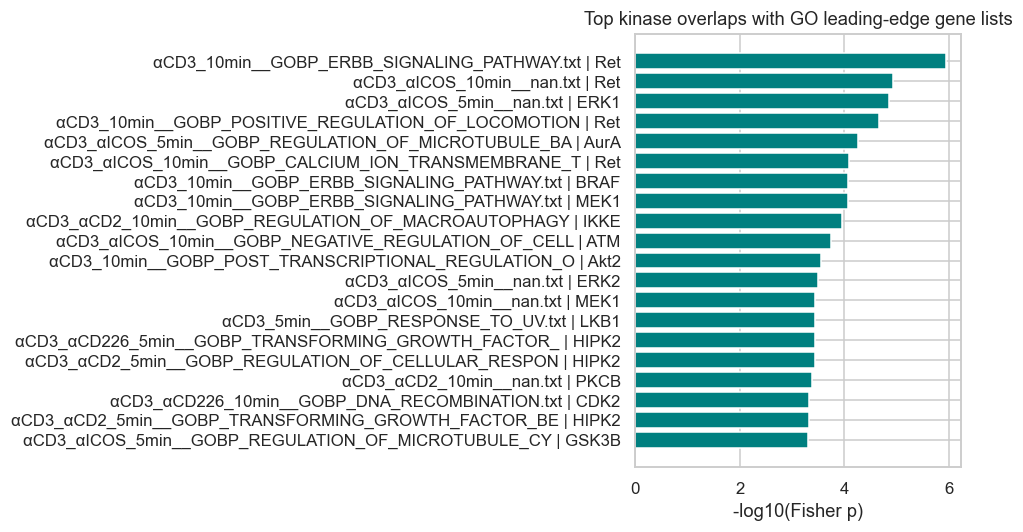

In [9]:
if FISHER_TSV.is_file():
    fish = pd.read_csv(FISHER_TSV, sep="\t")
    display(fish.nsmallest(15, "fisher_p_two_sided"))
    sub = fish.nsmallest(20, "fisher_p_two_sided").copy()
    sub["mlog10p"] = -np.log10(np.clip(sub["fisher_p_two_sided"].to_numpy(), 1e-300, None))
    fig, ax = plt.subplots(figsize=(9, 5))
    lab = sub["leading_edge_list"].astype(str).str[:50] + " | " + sub["kinase"].astype(str)
    ax.barh(lab, sub["mlog10p"], color="teal")
    ax.invert_yaxis()
    ax.set_xlabel("-log10(Fisher p)")
    ax.set_title("Top kinase overlaps with GO leading-edge gene lists")
    fig.tight_layout()
    plt.show()
else:
    print("No Fisher table at", FISHER_TSV, "— run analyze/leading_edge_kinase_overlap.py")


## GMT substrate coverage in `data.tsv`

For one **example kinase** (highest mean −log10 p across conditions), count how many GMT substrate genes appear as `geneid` in the phospho table.

In [10]:
mean_nlp = long.groupby("kinase")["neglog10p"].mean().sort_values(ascending=False)
example_kin = str(mean_nlp.index[0]) if len(mean_nlp) else None
print("Example kinase (max mean -log10 p):", example_kin)

if example_kin and GMT_SETS.get(example_kin) and DATA_TSV.is_file():
    genes_gmt = {g.upper() for g in GMT_SETS[example_kin]}
    dt = pd.read_csv(DATA_TSV, sep="\t", usecols=["geneid"], low_memory=False)
    in_data = set(dt["geneid"].astype(str).str.strip().str.upper())
    hit = genes_gmt & in_data
    print(f"Substrates in GMT: {len(genes_gmt)}; found in data.tsv: {len(hit)} ({100*len(hit)/max(len(genes_gmt),1):.1f}%)")
else:
    print("Skip coverage demo (missing GMT entry or data.tsv)")


Example kinase (max mean -log10 p): CK1A
Substrates in GMT: 59; found in data.tsv: 7 (11.9%)


---

*End of notebook.*